# Filters, from scratch

Take a bright, buzzy sawtooth wave and pass it through a filter. Turn the
filter's cutoff knob, and the sound opens and closes, like a mouth saying
"wow". Turn up its resonance, and it starts to sing and squelch.

Filters are at the heart of
[subtractive synthesis](https://en.wikipedia.org/wiki/Subtractive_synthesis): start from a waveform rich
in harmonics, and carve away the ones you don't want. Much of what makes one
synthesizer sound different from another is its filter.

In this notebook we will build a famous filter from scratch, the **ladder
filter**, the sound of the Moog synthesizers and, in a variation, of the
Roland TB-303. We will build it one small step at a time, and hear and see
what each step does.

You will need a little math (exponentials and a bit of trigonometry) and the
basics of synthesis: oscillators, envelopes and harmonics. If those are new to you, jupylet's
[Programming Synthesizers](https://jupylet.readthedocs.io/en/latest/programmers_reference_guide/synthesis.html)
guide is a good place to start. Everything else we will explain on the way.

## A little history

Before we write any code, let's meet the people and the machines behind these
filters.

**1930: Butterworth.** The British physicist
[Stephen Butterworth](https://en.wikipedia.org/wiki/Stephen_Butterworth) published a short paper, *On the
Theory of Filter Amplifiers*, about filters for radio valve amplifiers. He
wanted a filter that is as flat as possible over the frequencies it lets
through, with no bumps and no dips, and he worked out how to build one.

His design, the [Butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter), became one of the
standard filters of electronics. You can still find it today in audio
equipment, measuring instruments and loudspeakers.

**1966: the Moog ladder.** [Robert Moog](https://en.wikipedia.org/wiki/Robert_Moog) filed a
[patent](https://patents.google.com/patent/US3475623A/en) for a filter made of
four identical stages, each a capacitor and a pair of transistors, stacked
one on top of the other like the rungs of a ladder.

The patent already notes something wonderful: feed some of the output back
into the input, and the filter resonates. Feed back enough, and it sings all
by itself. Here is Moog with his synthesizers:

<a href="https://en.wikipedia.org/wiki/Robert_Moog"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/57/Bob_Moog3.jpg/960px-Bob_Moog3.jpg" alt="Robert Moog with his synthesizers" width="560"></a>

*Robert Moog with a Moog modular system and, front right, a Minimoog. Photo: Moog
Music, public domain, via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Bob_Moog3.jpg).*

The ladder became the heart of the
[Moog modular synthesizers](https://en.wikipedia.org/wiki/Moog_synthesizer) and of the
[Minimoog](https://en.wikipedia.org/wiki/Minimoog), a compact synthesizer made in 1970 for playing on
stage. Take a look; its filter knobs are in the Modifiers section on the right:

<a href="https://en.wikipedia.org/wiki/Minimoog"><img src="https://upload.wikimedia.org/wikipedia/commons/2/22/Minimoog.JPG" alt="Minimoog" width="480"></a>

*The Minimoog. Photo: Krash, public domain, via
[Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Minimoog.JPG).*

In 2013 the ladder filter earned Moog a posthumous place in the US
[National Inventors Hall of Fame](https://en.wikipedia.org/wiki/National_Inventors_Hall_of_Fame).

**1974: the state variable filter.** [Tom Oberheim](https://en.wikipedia.org/wiki/Tom_Oberheim)
went another way. His [SEM](https://en.wikipedia.org/wiki/Oberheim_SEM) (Synthesizer Expander Module) used
a [state variable filter](https://en.wikipedia.org/wiki/State_variable_filter), which puts out a lowpass,
a bandpass and a highpass all at once. It sounds gentler and brighter than the
ladder, and it is the other classic synth filter sound.

<a href="https://en.wikipedia.org/wiki/Oberheim_SEM"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/Oberheim_Dual_Manual_8Voice_SEM_units.jpg/960px-Oberheim_Dual_Manual_8Voice_SEM_units.jpg" alt="Oberheim SEM units" width="480"></a>

*SEM units in an Oberheim Eight Voice. Photo: Kevin Spencer,
CC BY 2.0, via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Oberheim_Dual_Manual_8Voice_SEM_units.jpg).*

**1981: the TB-303.** Roland's [TB-303](https://en.wikipedia.org/wiki/Roland_TB-303) Bass Line,
designed by [Tadao Kikumoto](https://en.wikipedia.org/wiki/Tadao_Kikumoto), was meant to replace the bass
guitar. It sounded nothing like one! It sold poorly, and Roland stopped making
it in 1984, a flop. Nobody could have guessed that three years later it would
give birth to a new genre of music, and become one of the most iconic
synthesizers ever made (more on that below).

<a href="https://en.wikipedia.org/wiki/Roland_TB-303"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/Roland_TB-303_Panel.jpg/960px-Roland_TB-303_Panel.jpg" alt="Roland TB-303" width="560"></a>

*The TB-303. Photo: Steve Sims, CC0, via
[Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Roland_TB-303_Panel.jpg).*

Its filter is a ladder too, built from diodes instead of transistor pairs. The
diodes couple its four stages, so that it behaves a bit like a three stage
filter, and people still argue whether it cuts 18dB or 24dB per octave.

**1984: the Xpander.** Oberheim's [Xpander](https://en.wikipedia.org/wiki/Oberheim_Xpander) had a
clever trick. It tapped the outputs of the four stages of its ladder and mixed
them in different amounts, to get 15 different filters out of one ladder:
lowpass, highpass, bandpass, notch and more. We will use the same trick.

<a href="https://en.wikipedia.org/wiki/Oberheim_Xpander"><img src="https://upload.wikimedia.org/wikipedia/commons/7/72/Oberheim_Xpander.jpg" alt="Oberheim Xpander" width="560"></a>

*The Oberheim Xpander. Photo: Bill.lay, CC BY-SA 3.0, via
[Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Oberheim_Xpander.jpg).*

**1987: acid.** In Chicago, three friends,
[DJ Pierre](https://en.wikipedia.org/wiki/DJ_Pierre), Spanky and Herb Jackson, bought a second hand 303
and jammed with it, turning its filter knobs by hand. By their own account,
they had no idea how it was supposed to work.

They gave a tape to the DJ [Ron Hardy](https://en.wikipedia.org/wiki/Ron_Hardy), who played it at his
club, the Muzic Box. The first time, the dance floor emptied. He played it
again, and again, and by the fourth time that night the crowd went wild. Fans
taping the club's music called it *Ron Hardy's Acid Track*.

In 1987 the group, [Phuture](https://en.wikipedia.org/wiki/Phuture), released it as
[*Acid Tracks*](https://en.wikipedia.org/wiki/Acid_Tracks): twelve minutes of squelching 303 that started
[acid house](https://en.wikipedia.org/wiki/Acid_house), and turned the failed bass machine into one of the
most sought after synthesizers in dance music.
[Have a listen](https://www.youtube.com/watch?v=igNBeo3QSqc).

**2004: the digital ladder.** All the filters above are electronic circuits:
capacitors, transistors and diodes, with current flowing through them. Many
synthesizers today are software instead, and their filters are *computational
models* of such circuits: a few lines of code that work out, sample by sample,
what the circuit would do.

The hard part is that real circuits are not perfect. Their transistors
saturate, and their parts affect one another, and much of the character people
love comes from those imperfections. In 2004, Antti Huovilainen published a
[digital model of the Moog ladder](https://dafx.de/paper-archive/2004/P_061.PDF)
that keeps the saturation of its transistors. The ladder we will build in this
notebook is a simplified version of his model.

## Setup

Let's start by importing what we need: numpy for arrays of numbers, numba to
make our loops fast (more on that soon), and jupylet's audio bundle, which
brings in its tools for making, playing and plotting sounds, and the names of
all the notes, from C1 to B7.

In [1]:
import math
import sys
import os

import numpy as np

# numba compiles Python loops to fast machine code.
import numba

# Use the jupylet in the folder above this notebook.
sys.path.insert(0, os.path.abspath('./..'))

# Jupylet's audio tools, and the note names from C1 to B7, like C4 for
# middle C.
from jupylet.audio.bundle import *

Digital sound is a long sequence of numbers, called samples, each the value
of the audio signal at one instant, taken at regular intervals. On playback, a
[digital-to-analog converter](https://en.wikipedia.org/wiki/Digital-to-analog_converter)
turns them back into a continuous voltage that drives the speakers.

Jupylet, like a CD, uses 44100 samples for every second of sound; that is the
[sample rate](https://en.wikipedia.org/wiki/Sampling_(signal_processing)). We will call it `FS`, for
sampling frequency:

In [2]:
# The sampling frequency, fs in the formulas: samples per second.
FS = 44100

## White noise

A surprising fact about sound is that any sound can be described as a
combination of simple sine waves, each with its own frequency and strength.
For a beautiful visual explanation, watch 3Blue1Brown's
[*But what is the Fourier Transform?*](https://www.youtube.com/watch?v=spUNpyF58BY).
A filter works by letting some of these frequencies through, and weakening
others.

Our first test sound is [white noise](https://en.wikipedia.org/wiki/White_noise):
a sequence of random numbers. As it turns out, white noise contains all
frequencies at roughly equal strength, and that makes it perfect for seeing
what a filter does to each frequency.

Jupylet's `Noise` generator makes it. Like every jupylet sound, you call it
with the number of frames (samples) you want. Let's make 32 seconds of it.
That is long, but the longer the noise, the cleaner its spectrum plots will be:

In [3]:
# 32 seconds of white noise; [:, 0] takes its one channel as a plain
# array.
noise = Noise('white')(frames=32*FS)[:, 0]

Let's see what it looks like, with jupylet's `plot()`:

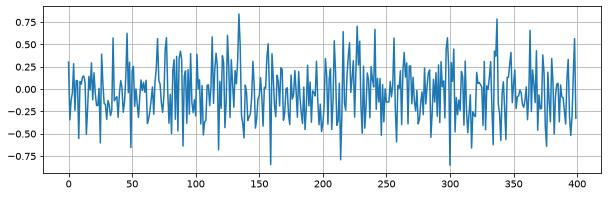

In [4]:
# The first 400 samples, less than a hundredth of a second.
plot(noise[:400], figsize=(10, 3))

Every sample jumps at random. To hear it we will use jupylet's `play()`,
which plays an array of samples through the speakers. Some sounds in this
notebook are loud, so turn your speakers down a little first:

In [5]:
# Play the first two seconds.
play(noise[:2*FS])

A hiss, like rain, or a radio tuned between stations.

Now let's look at its **spectrum**: the strength of each frequency in it.
Jupylet's `get_power_spectrum_plot()` breaks the sound down into its sine waves
with the [fast Fourier transform](https://en.wikipedia.org/wiki/Fast_Fourier_transform)
(FFT), and plots them.

We will plot frequency on a logarithmic axis, where every octave takes the same
width, like the keys of a piano:

In [6]:
# A logarithmic frequency axis, from 100Hz up to FS / 2.
log_axis = dict(xscale='log', xlim=(100, FS / 2))

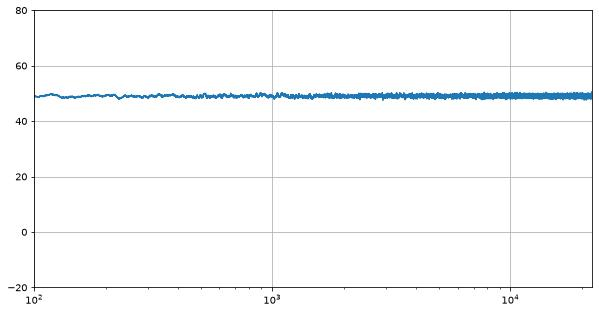

In [7]:
get_power_spectrum_plot(noise, ylim=(-20, 80), **log_axis)

Flat, as promised: all frequencies at roughly equal strength.

If this is your first spectrum plot, here is how to read it. The horizontal
axis is frequency, in Hz: vibrations per second. It is logarithmic, so the
labels 10², 10³ and 10⁴ mark 100Hz, 1000Hz and 10000Hz, each ten times the one
before. Middle C, at about 261Hz, sits between the first two.

The vertical axis is strength, in [decibels](https://en.wikipedia.org/wiki/Decibel)
(dB), which are logarithmic too, much like our hearing: a sound 10dB stronger
sounds about twice as loud. The level itself, about 49dB here, does not
matter. What we will look at is how far below it a filtered sound falls.

## Sawtooth wave

Our second test sound is a [sawtooth wave](https://en.wikipedia.org/wiki/Sawtooth_wave),
the classic raw material of synth sounds, from basses to leads. White noise is
good for measuring a filter, but a sawtooth is what a synthesizer actually
filters, so this is the one we will listen to.

Let's make one at middle C with jupylet's `Oscillator`. Jupylet names notes
the way musicians do, so middle C is simply `C4`:

In [8]:
# Two seconds of a sawtooth at middle C.
saw = Oscillator('sawtooth', key=C4)(frames=2 * FS)[:, 0]

Let's see what it looks like; here are its first three cycles:

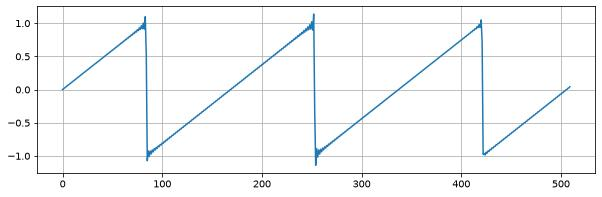

In [9]:
# 44100 / 261.6: about 169 samples for each cycle.
plot(saw[:510], figsize=(10, 3))

It rises steadily and drops sharply, about 261 times a second. See the little
ripples at each drop? They are actually a good thing!

A digital sound cannot hold frequencies above half its sample rate, 22050Hz,
the [Nyquist frequency](https://en.wikipedia.org/wiki/Nyquist_frequency). A perfectly sharp drop would contain such frequencies, and
they would show up in disguise, as lower tones that were never there, out of
tune with the note. This effect is called
[aliasing](https://en.wikipedia.org/wiki/Aliasing). Jupylet's oscillators leave
them out, and the ripples are what a sawtooth looks like without them.

Let's hear it:

In [10]:
play(saw)

Bright and buzzy. The spectrum shows where that comes from.

By default, `get_power_spectrum_plot()` smooths the plot by averaging
neighboring frequencies, which suits jagged noise. The sawtooth is made of
sharp spikes, so this time we plot each frequency on its own:

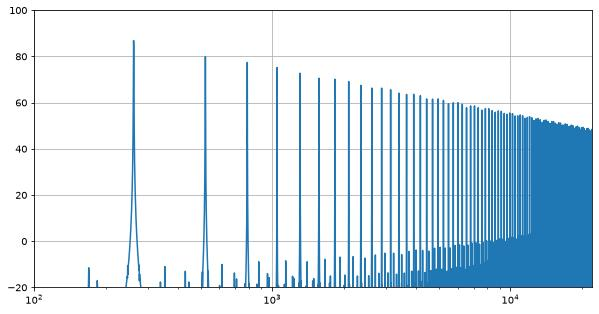

In [11]:
# window=1: no smoothing.
get_power_spectrum_plot(saw, window=1, ylim=(-20, 100), **log_axis)

A spike at middle C and at every multiple of it: 523Hz, 785Hz, 1047Hz and so
on. These are its [harmonics](https://en.wikipedia.org/wiki/Harmonic). Each is
a little weaker than the one before. The ninth, for example, is about 19dB
below the first, so it sounds roughly a quarter as loud. They go on up to just
below the Nyquist frequency, the highest frequency digital sound can hold.

Look closely and you will also see tiny spikes between the harmonics, some 90dB
below the note, far too quiet to hear under it. They are a side effect of the
optimized algorithm that keeps jupylet's oscillator fast.

Now we have everything we need. Let's build a filter!

# The ladder filter

We already met Moog's ladder in the history above: four identical stages
stacked like the rungs of a ladder, with some of the output fed back into the
input. It sounds like a lot of electronics, but each part turns out to be
simple on its own, and we will build it in code, one part at a time.

We will start with the simplest filter there is, one that follows the sound,
but a little slowly, and so smooths away its fastest wiggles. We will hear
what it does to white noise and to the sawtooth. Then we will stack four of
them, add the feedback that makes the ladder sing, and let it saturate the way
the transistors of the real circuit do. By the end we will have a fully
working classic ladder filter.

At every step we will look at the sound, listen to it, and measure its
spectrum.

## Step 1: A chaser

The simplest electronic filter is a [resistor and a capacitor](https://en.wikipedia.org/wiki/RC_circuit). A
capacitor stores electric charge, a bit like a bucket stores water, and the
resistor is like a narrow pipe it fills through. Apply a voltage to the input,
and the capacitor's voltage rises towards it, but it can't get there at once:
the charge takes time to flow through the resistor. The bigger the gap between
the input and the capacitor, the faster the charge flows, so the capacitor
closes the gap quickly at first, then slower and slower. It chases the input.

If the input voltage changes slowly, the capacitor keeps up with it. But a fast
wiggle is over before the capacitor has moved much, so it hardly shows at the
output. Slow changes pass, and fast ones are smoothed away: this is a
[**lowpass filter**](https://en.wikipedia.org/wiki/Low-pass_filter).

In code, we do the same thing one sample at a time. `x` represents the input
voltage, and `y` represents the capacitor's voltage. At each sample, `y`
closes a fraction `g` of the gap between itself and the input:

```
y += g * (x - y)
```

In Python, `y += a` is short for `y = y + a`: take `y`, add `a` to it, and
store the result back in `y`. It is an instruction, not an equation as in math.
So at each sample, `y` moves by `g` times the gap `x - y`, a step closer to the
input value `x`.

With `g` close to 1, `y` follows quickly, and with `g` close to 0, `y`
follows slowly. We will call it the chaser. Statisticians know the same
formula as [exponential smoothing](https://en.wikipedia.org/wiki/Exponential_smoothing).

The formula works on one sample at a time. But a sound is a long list of
samples, and in Python we keep them in a numpy array: a list of numbers that
numpy can work with quickly. The noise and the sawtooth we made above are such
arrays, and `saw[0]` is the first sample of the sawtooth, `saw[1]` the second,
and so on.

So the chaser below takes the input sound `x`, an array of samples, and
returns the filtered sound `out`, an array of the same length. It goes over the
input one sample at a time, in a loop:

- `y` starts at 0: the capacitor starts empty.
- `out` starts as an array of zeros, one for each input sample, to be filled
  in.
- For each input sample `x[i]`, `y` takes a step closer to it, and its new
  value is stored in `out[i]`.

In [12]:
# The chaser, in plain Python. x is the input sound, an array of
# samples.
def chaser(x, g):

    # The capacitor starts empty.
    y = 0.

    # An array of zeros, one for each input sample, to hold the
    # output.
    out = np.zeros(len(x))

    for i in range(len(x)):

        # Take a step closer to the input sample x[i], and store the
        # result.
        y += g * (x[i] - y)
        out[i] = y

    return out

Let's use this code to chase a
[step function](https://en.wikipedia.org/wiki/Heaviside_step_function), an
input that jumps from 0 to 1, using three different values of `g`:

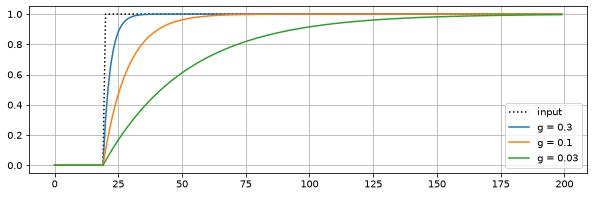

In [13]:
# A step function: 0 for 20 samples, then 1.
step = np.ones(200)
step[:20] = 0

# 'k:' draws a black dotted line, '-' a solid one.
plot(
    step, 'k:', 
    chaser(step, 0.3), '-', 
    chaser(step, 0.1), '-', 
    chaser(step, 0.03), '-',
    labels=['input', 'g = 0.3', 'g = 0.1', 'g = 0.03'],
    figsize=(10, 3),
)

Now let's pass the sawtooth through the chaser with `g = 0.02`, and plot its
first three cycles before and after. Notice how the chaser smooths out the
sharp drops of the sawtooth. It takes high frequency harmonics to make a drop
that sharp, so smoothing it out means weakening those harmonics.

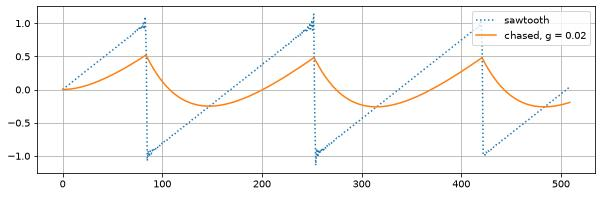

In [14]:
# The first three cycles, before and after the chaser.
plot(
    saw[:510], ':', chaser(saw, 0.02)[:510], '-',
    labels=['sawtooth', 'chased, g = 0.02'],
    figsize=(10, 3),
)

Let's hear it. The buzz is gone, and what is left sounds soft and muffled, as
if through a wall:

In [15]:
# The sawtooth, chased with g = 0.02.
play(chaser(saw, 0.02))

And here is what the chaser does to white noise, for two values of `g`. The
noise comes out unchanged at low frequencies, and falls away above a certain
frequency, the **cutoff**.

Above the cutoff it falls in a straight line, 6dB for every
[octave](https://en.wikipedia.org/wiki/Octave). An octave is a doubling of frequency, like from one C to
the next C up on the piano. And 6dB weaker means half the
[amplitude](https://en.wikipedia.org/wiki/Amplitude), how far the wave swings up and down. So each time the
frequency doubles, the chaser lets through half as much of it.

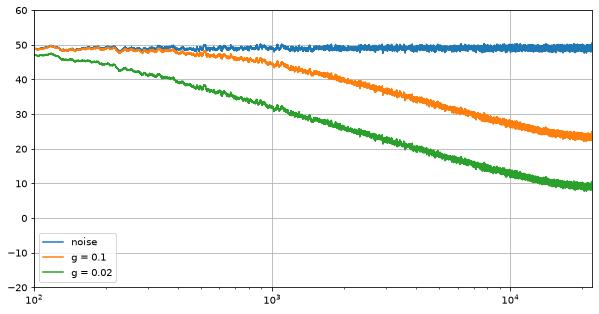

In [16]:
# White noise, before and after the chaser, with two values of g.
get_power_spectrum_plot(
    noise, chaser(noise, 0.1), chaser(noise, 0.02),
    labels=['noise', 'g = 0.1', 'g = 0.02'],
    ylim=(-20, 60),
    **log_axis,
)

### How fast is it?

Our chaser is plain Python. Let's see how long it takes to filter the two
seconds of the sawtooth. Jupyter's `%timeit` runs a line many times and
reports how long it took on average:

In [17]:
%timeit -n20 chaser(saw, 0.02)

7.92 ms ± 247 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)


It takes a few thousandths of a second to filter two seconds of sound, so plain
Python is fast enough here. But the chaser is the simplest filter there is. The
ladder we are going to build does much more work for each sample, and a
synthesizer runs one for every note it plays, along with its oscillators and
effects, all in real time. For that, we need our loops to run much faster.

This is where [numba](https://numba.pydata.org/) comes in.
[Decorate](https://docs.python.org/3/glossary.html#term-decorator) a function
with `@numba.njit`, and numba will compile it to machine code the first time it
is called, as if it were written in C. Here is the same chaser, compiled:

In [18]:
# The same chaser, compiled by numba the first time it is called.
@numba.njit
def chaser(x, g):

    # The capacitor starts empty.
    y = 0.

    # An array of zeros, one for each input sample, to hold the
    # output.
    out = np.zeros(len(x))

    for i in range(len(x)):

        # Take a step closer to the input sample x[i], and store the
        # result.
        y += g * (x[i] - y)
        out[i] = y

    return out

In [19]:
%timeit -n200 chaser(saw, 0.02)

203 μs ± 129 μs per loop (mean ± std. dev. of 7 runs, 200 loops each)


More than 50 times faster (the exact numbers depend on your computer). From here
on, every filter we write will be decorated with `@numba.njit`.

## Step 2: From a cutoff frequency to g

A musician thinks in frequencies, not in fractions: we want to say where the
filter should cut, and get the `g` that cuts there.

First, what exactly is the cutoff frequency? Engineers define it as the
frequency at which the filter weakens the sound by 3dB. At lower frequencies,
the sound passes almost unchanged, and at higher frequencies, it is weakened
more and more.

The formula for `g` comes from the physics of the resistor and capacitor of
step 1. Its derivation is beyond the scope of this guide, so we will take it
as given:

$$g = 1 - e^{-2 \pi f_c / f_s}$$

where $f_c$ is the cutoff frequency and $f_s$ is the sampling frequency, `FS`.
The higher the cutoff, the bigger `g`, and the faster `y` follows the input.
For a cutoff of 1000Hz, `g` is about 0.13: at each sample, the chaser closes
13% of the gap.

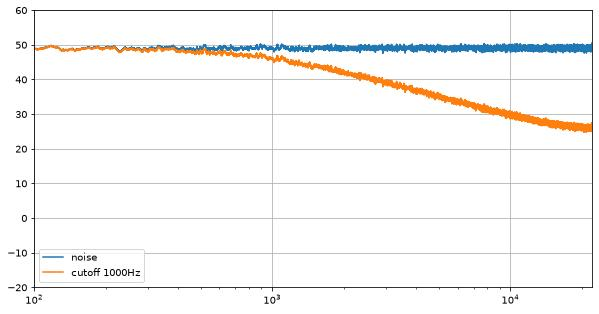

In [20]:
# The g that gives a chaser the given cutoff frequency, in Hz. It is
# compiled with numba, so that our compiled filters can use it too.
@numba.njit
def cutoff2g(cutoff):
    return 1 - math.exp(-2 * math.pi * cutoff / FS)


get_power_spectrum_plot(
    noise, chaser(noise, cutoff2g(1000)),
    labels=['noise', 'cutoff 1000Hz'],
    ylim=(-20, 60),
    **log_axis,
)

At 1000Hz the filtered noise is 3dB below the noise, as it should be. From
here on we will call the chaser by its engineering name, a **one pole lowpass
filter**. A pole is a term from the math of filters; for now, count one pole
for each chaser.

## Step 3: Four chasers in a row

The chaser is a gentle filter. Remember the sawtooth in step 1: to muffle it,
we used `g = 0.02`, which puts the cutoff at about 140Hz, far below the note
itself, middle C at 261Hz. That's because above its cutoff, the chaser weakens
the sound's harmonics by only 6dB more for every octave.

For a steeper filter, we put chasers in a row, each chasing the one before.
Each chaser adds another 6dB per octave, so four of them cut 24dB per octave.
That is the ladder: four identical stages, the rungs of Moog's ladder.

In [21]:
@numba.njit
def four_chasers(x, cutoff):

    # The g of each chaser, from the cutoff frequency, as in step 2.
    g = cutoff2g(cutoff)

    y1 = y2 = y3 = y4 = 0.
    out = np.zeros(len(x))

    for i in range(len(x)):
        # Each stage chases the one before it.
        y1 += g * (x[i] - y1)
        y2 += g * (y1 - y2)
        y3 += g * (y2 - y3)
        y4 += g * (y3 - y4)
        out[i] = y4

    return out

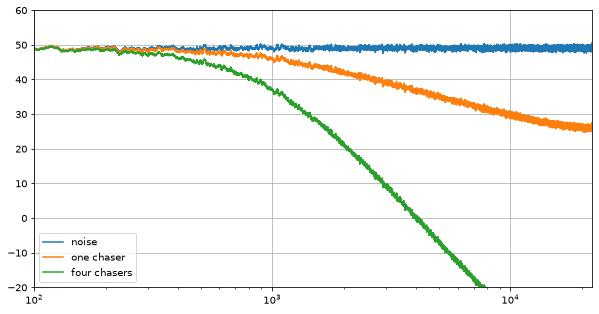

In [22]:
#
# Compare one chaser with four chasers in a row, each with its
# cutoff at 1000Hz.
#

get_power_spectrum_plot(
    noise, chaser(noise, cutoff2g(1000)), four_chasers(noise, 1000),
    labels=['noise', 'one chaser', 'four chasers'],
    ylim=(-20, 60),
    **log_axis,
)

The slope is four times steeper, but look at the cutoff. Each stage loses 3dB
there, so four lose 12dB, and the filter starts falling well before the
cutoff. The knee is soft and droopy. In the next section we will see how
resonance sharpens it.

Now let's pass the sawtooth through four chasers with the cutoff at 500Hz, and
plot its first three cycles before and after. Notice how the four chasers turn
it into a smooth wave, almost a sine wave, since most of its harmonics are
gone. Notice also that it lags behind the sawtooth. We will come back to that
in the next section.

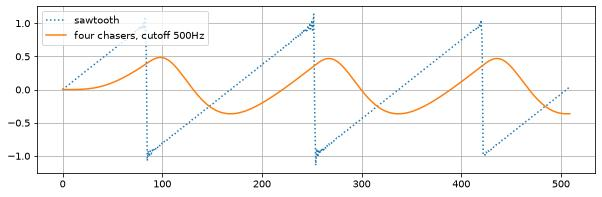

In [23]:
# The first three cycles, before and after four chasers with the
# cutoff at 500Hz.
plot(
    saw[:510], ':', four_chasers(saw, 500)[:510], '-',
    labels=['sawtooth', 'four chasers, cutoff 500Hz'],
    figsize=(10, 3),
)

Now let's listen. The buzz is gone, leaving a dark, round tone:

In [24]:
# Four chasers, with the cutoff at 500Hz.
play(four_chasers(saw, 500))

## Step 4: Feedback and resonance

Now for Moog's trick: feed some of the output back into the input. Subtract
`r` times the output from the input,

```
u = x - r * y4
```

and feed `u` into the first stage instead of `x`.

In [25]:
@numba.njit
def resonant_chasers(x, cutoff, r):

    # The g of each chaser, from the cutoff frequency, as in step 2.
    g = cutoff2g(cutoff)

    y1 = y2 = y3 = y4 = 0.
    out = np.zeros(len(x))

    for i in range(len(x)):
        # Feedback: subtract r times the output of the previous
        # sample.
        u = x[i] - r * y4
        y1 += g * (u - y1)
        y2 += g * (y1 - y2)
        y3 += g * (y2 - y3)
        y4 += g * (y3 - y4)
        out[i] = y4

        #
        # WARNING: do not remove this check. It stops the filter as
        # soon as its output passes 3, protecting you from a runaway
        # sound blasting out at full volume.
        #
        if abs(y4) > 3:
            raise ValueError('The filter ran away: its output passed 2.')

    return out

Subtracting the output sounds like it would just make the sound weaker, and at
most frequencies it does. But there is a twist. A chaser always lags behind its
input, and at the cutoff frequency each one lags about an eighth of a cycle.
Four of them in a row lag about half a cycle. Let's see it, with a sine wave
at the cutoff frequency:

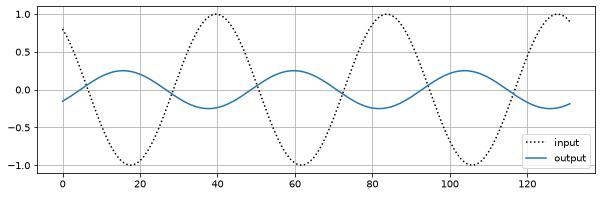

In [26]:
# A second of a sine wave at 1000Hz, through four chasers with their
# cutoff at 1000Hz.
sine = np.sin(2 * math.pi * 1000 * np.arange(FS) / FS)
out = four_chasers(sine, 1000)

# Three cycles, once the chasers have settled.
plot(
    sine[2000:2132], 'k:', out[2000:2132], '-',
    labels=['input', 'output'],
    figsize=(10, 3),
)

The output is upside down: it is high where the input is low, and low where
it is high. Keep in mind that this plot shows four chasers *without* feedback.
It shows what the chasers do to whatever goes into them, and that gives us a
hint of what the feedback will do.

Now let's consider what the feedback does. It subtracts `r` times this upside
down output from `x`, and subtracting an upside down wave is the same as adding
it upright. So at the cutoff frequency, the feedback adds to `x`, and the
chasers get a stronger sine wave than `x` alone. A stronger input to the
chasers makes a stronger output, and a stronger feedback, until the loop
settles at a higher level. The result is a peak in the spectrum, right at the
cutoff frequency: **resonance**.

<div class="alert alert-block alert-info">

**For the curious: how high the peak gets**

The feedback does not simply add the plot's quarter-size wave to $x$, because
the chasers' input $u$ already includes the feedback itself. Here is how to
work it out. In the code, the chasers' input is

$$u = x - r \cdot y_4$$

For a sine wave at the cutoff frequency, the chasers turn $u$ into an output a
quarter its size and upside down, so $y_4 = -u / 4$. Putting that into the
equation above, and solving for $u$:

$$\begin{aligned} u &= x + r u / 4 \\ u - r u / 4 &= x \\ u (1 - r / 4) &= x \\ u &= \frac{x}{1 - r / 4} \end{aligned}$$

The output is a quarter of $u$, upside down:

$$y_4 = -\frac{u}{4} = -\frac{x}{4 - r}$$

At $r = 0$ this is the plot's quarter-size wave, $-x / 4$. At $r = 1$ it is
$-x / 3$, at $r = 2$ it is $-x / 2$, and at $r = 3$ it is as big as $x$. As $r$
approaches 4, $4 - r$ approaches zero, and the output grows without limit: at
$r = 4$ there is no balance left for the loop to settle into.

In practice, the runaway threshold of our digital filter is higher than 4,
and it depends on the cutoff frequency. With the cutoff at 1000Hz, for
example, it runs away at about $r = 4.64$. The reason is that at the cutoff,
our four chasers shift the phase of the wave by 164° rather than 180°, half a
cycle, and the feedback, by using the output of the previous sample, adds
another 8°. Together that is 172°, still short of upside down. The loop
reaches a full 180° only at a slightly higher frequency, where the chasers let
less of the wave through, so more feedback is needed before it runs away.

</div>

Let's start with a little feedback, `r = 1`, and compare it with none. Notice
how the knee gets sharper:

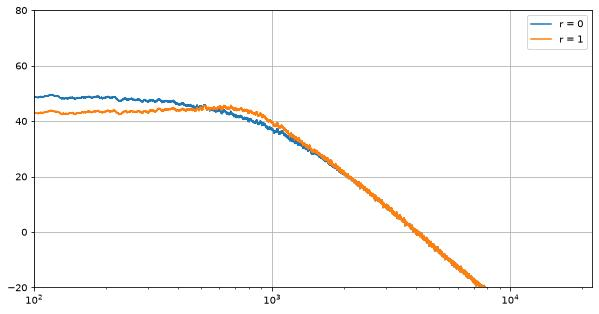

In [27]:
#
# Noise through the ladder with the cutoff at 1000Hz, without feedback
# and with r = 1.
#

get_power_spectrum_plot(
    *[resonant_chasers(noise, 1000, r) for r in (0, 1)],
    labels=['r = %s' % r for r in (0, 1)],
    ylim=(-20, 80),
    **log_axis,
)

Now let's turn the feedback up, all the way to `r = 3.8`:

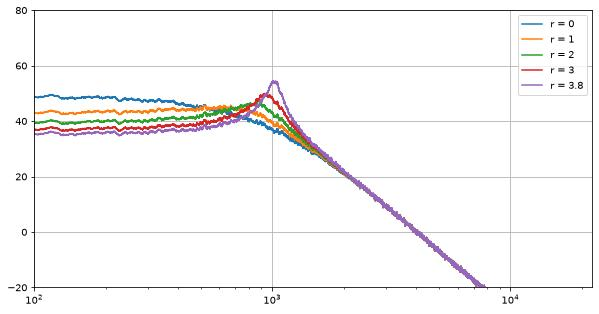

In [28]:
#
# Noise through the ladder with the cutoff at 1000Hz, with more and
# more feedback.
#

get_power_spectrum_plot(
    *[resonant_chasers(noise, 1000, r) for r in (0, 1, 2, 3, 3.8)],
    labels=['r = %s' % r for r in (0, 1, 2, 3, 3.8)],
    ylim=(-20, 80),
    **log_axis,
)

Two things to notice. The peak grows as `r` approaches 4, and the low
frequencies drop: the feedback subtracts them. That loss of bass as the
resonance goes up is part of the ladder's sound.

Now the sawtooth, with the cutoff at 1000Hz and a lot of resonance. Look what
happens after each drop: the filter rings, a wiggle at the cutoff frequency
that slowly dies out:

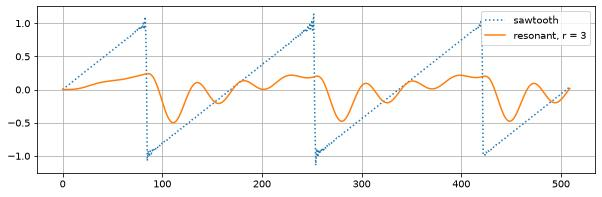

In [29]:
# The first three cycles, with the cutoff at 1000Hz and r = 3.
plot(
    saw[:510], ':', resonant_chasers(saw, 1000, 3.)[:510], '-',
    labels=['sawtooth', 'resonant, r = 3'],
    figsize=(10, 3),
)

That ringing is what resonance sounds like. Let's listen to it: first the
plain sawtooth, then through the ladder with more and more feedback. Listen
for a nasal, vowel-like tone growing on top of the note:

In [30]:
# The plain sawtooth, for comparison, at half its level to match the
# loudness of the filtered versions.
play(saw / 2)

In [31]:
# Cutoff at 1000Hz, r = 0.
play(resonant_chasers(saw, 1000, 0))

In [32]:
# Cutoff at 1000Hz, r = 1.
play(resonant_chasers(saw, 1000, 1))

In [33]:
# Cutoff at 1000Hz, r = 3.
play(resonant_chasers(saw, 1000, 3.))

Here is the spectrum of the last one, with `r = 3`. We use eight seconds of
the sawtooth this time, for a cleaner plot:

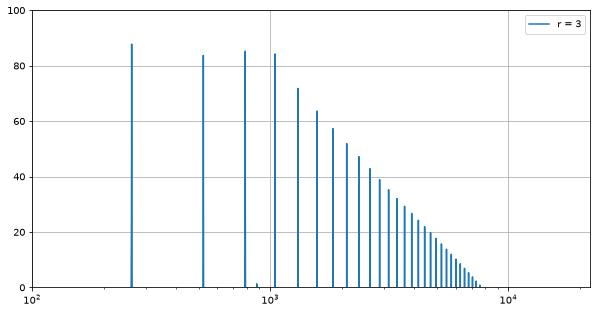

In [34]:
#
# The spectrum of eight seconds of the sawtooth, through the ladder
# with the cutoff at 1000Hz and r = 3.
#

get_power_spectrum_plot(
    resonant_chasers(
        Oscillator('sawtooth', key=C4)(frames=8 * FS)[:, 0],
        1000,
        3.,
    ),
    labels=['r = 3'],
    window=1,
    ylim=(0, 100),
    **log_axis,
)

Notice the hump around the cutoff: the harmonics near 1000Hz are stronger
than the lower harmonics, and the higher harmonics grow steadily weaker. A
hump like this, called a [formant](https://en.wikipedia.org/wiki/Formant), is
what our ears use to tell vowels, and instruments, apart. Brass instruments
have one around 1000Hz, which is why this sound has a slightly brassy
character.

## Step 5: Saturation

In an analog electronic circuit, the ladder's transistors do not respond in a
straight line. Small signals pass almost unchanged, but big ones are squashed,
more and more, towards a limit. The function [`tanh`](https://en.wikipedia.org/wiki/Hyperbolic_functions) does exactly that:

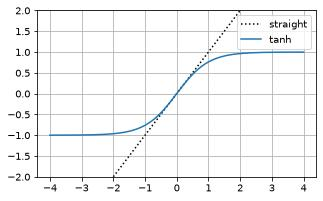

In [35]:
# 200 values from -4 to 4.
v = np.linspace(-4, 4, 200)

plot(v, v, 'k:', v, np.tanh(v), labels=['straight', 'tanh'], ylim=(-2, 2), figsize=(5, 3))

In the circuit, each stage compares its input with its own output through such
a squashing curve. So in the model, the gap each stage chases is between the
tanh of the input and the tanh of its own output, and the input to the ladder
is squashed too. A `drive` factor sets how hard the input is pushed into the
curve: at small levels the filter is clean, and turned up it distorts,
warmly, the way analog circuits do.

This is the simplified form of Huovilainen's model:

In [36]:
@numba.njit
def saturated_ladder(x, cutoff, r, drive):

    # The g of each chaser, from the cutoff frequency, as in step 2.
    g = cutoff2g(cutoff)

    y1 = y2 = y3 = y4 = 0.
    out = np.zeros(len(x))

    #
    # Make up for the level lost at low drive, where the filter is
    # nearly linear, so its output is the drive times the full level.
    # Above 1, driving harder is meant to be louder.
    #
    makeup = 1 / min(drive, 1.)

    for i in range(len(x)):
        # The input and every stage go through tanh, like the
        # transistors of the ladder.
        u = math.tanh(drive * x[i] - r * y4)
        y1 += g * (u - math.tanh(y1))
        y2 += g * (math.tanh(y1) - math.tanh(y2))
        y3 += g * (math.tanh(y2) - math.tanh(y3))
        y4 += g * (math.tanh(y3) - math.tanh(y4))
        out[i] = y4 * makeup

        #
        # WARNING: do not remove this check. It stops the filter as
        # soon as its output passes 3, protecting you from a runaway
        # sound blasting out at full volume.
        #
        if abs(out[i]) > 3:
            raise ValueError('The filter ran away: its output passed 2.')

    return out

Let's start with a simple wave, to see what saturation does on its own.
Here is a sine wave at middle C through the ladder, without resonance, first
played softly and then driven hard. Here are three cycles of each, scaled to
the same height to compare their shapes:

In [37]:
# Two seconds of a sine wave at middle C.
sine = Oscillator('sine', key=C4)(frames=2 * FS)[:, 0]

In [38]:
soft = saturated_ladder(sine, 1000, 0., 0.1)
hard = saturated_ladder(sine, 1000, 0., 4.)

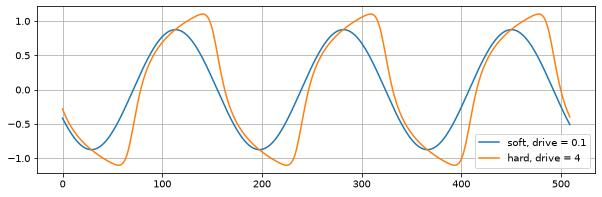

In [39]:
# Three cycles of each, once the filter has settled, scaled to the
# same height.
plot(
    soft[4000:4510], '-',
    hard[4000:4510], '-',
    labels=['soft, drive = 0.1', 'hard, drive = 4'],
    figsize=(10, 3),
)

Driven hard, the sine is bent out of shape: it rises slowly and falls
steeply. Let's listen, the soft one first, both at the same level:

In [40]:
play(soft)

In [41]:
play(hard)

Driven hard, the sine gains new harmonics: the 3rd, the 5th, the 7th and
so on. Only odd ones, because tanh squashes the top and the bottom of the
wave alike. This is the distortion of an analog circuit pushed hard.

A sawtooth already has every harmonic, so for it saturation does something
else. Here it is with the cutoff at 1000Hz and `r = 3`, as in step 4, played
softly and then driven hard, three cycles of each, scaled to the same height:

In [42]:
soft = saturated_ladder(saw, 1000, 3., .1)
hard = saturated_ladder(saw, 1000, 3., 4.)

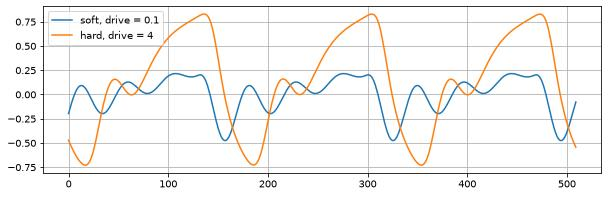

In [43]:
plot(
    soft[4000:4510], '-',
    hard[4000:4510], '-',
    labels=['soft, drive = 0.1', 'hard, drive = 4'],
    figsize=(10, 3),
)

Played softly, the filter rings after each drop of the sawtooth, just like
the one in step 4. Driven hard, the ringing is almost gone: the louder the
input, the more the saturation holds the resonance back. So the same knob
settings sound different depending on how hard you play. Let's listen:

In [44]:
play(soft)

In [45]:
play(hard)

And their spectra:

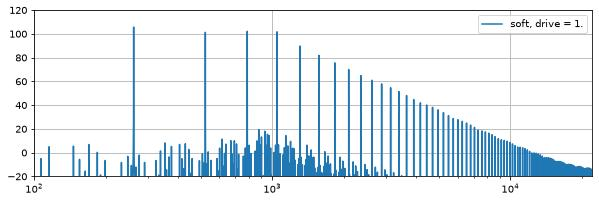

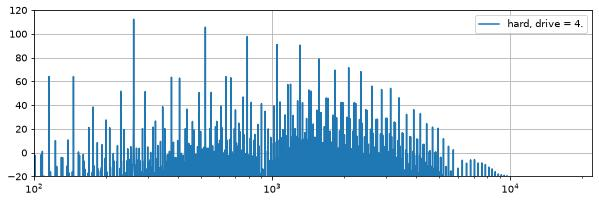

In [46]:
saw32 = Oscillator('sawtooth', key=C4)(frames=32 * FS)[:, 0]

soft32 = saturated_ladder(saw32, 1000, 3., .1)
hard32 = saturated_ladder(saw32, 1000, 3., 4.)
    
for y, label in [
    (soft32, 'soft, drive = 1.'),
    (hard32, 'hard, drive = 4.'),
]:
    display(get_power_spectrum_plot(
        y / np.abs(y).max(),
        labels=[label],
        window=1,
        ylim=(-20, 120),
        figsize=(10, 3),
        **log_axis,
    ))

And the filter can no longer run away. With `r` past the point where the
filter of step 4 ran away, it rings on by itself, at a steady level, as a sine
wave at the cutoff frequency. A single click is enough to start it:

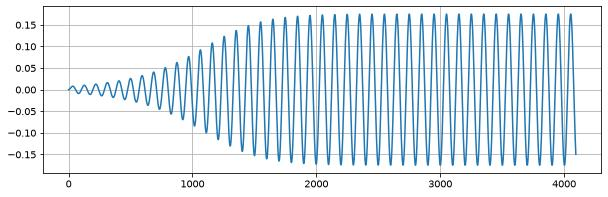

In [47]:
# One second of silence, but for a click at the first sample.
click = np.zeros(FS)
click[0] = 1

y = saturated_ladder(click, 440, 5., 1.)

plot(y[:4096], figsize=(10, 3))

It rings on for the whole second, a pure tone at the cutoff frequency, 440Hz,
the note A4:

In [48]:
# The click, rung by the filter.
play(normalized(y))

## Step 7: Highpass and bandpass

So far, every filter we have built has been a lowpass: it lets the lower
frequencies pass and weakens the higher ones. A **highpass** filter does the
opposite. It lets the higher frequencies pass and weakens the lower ones, so
the sound becomes thin and bright. A **bandpass** filter lets through only a
band of frequencies around its cutoff, and weakens both the lower and the
higher ones. As we will see now, a simple trick lets us make both of these new
kinds of filters from our good old lowpass chasers.

Think of the chaser as a function $C$. Apply it to an input sound $x$, and you
get an output sound $y = C(x)$, which keeps the low frequencies of $x$ and
weakens the high ones. Now subtract the output from the input: $x - C(x)$ is
what the chaser took away, the high frequencies of $x$. That is a highpass
filter, made of one chaser and a subtraction. It may be surprising that sounds can be
added and subtracted like numbers in an equation, but it turns out they can:
two sounds played together are simply the sum of their waves, and taking one
away leaves the other.

Our symbol for the chaser is $C$, and we apply it as $y = C(x)$. But what
symbol should we use for our new filter, $y = x - C(x)$? Rather than invent a
new letter, we can follow the conventions of
[linear algebra](https://en.wikipedia.org/wiki/Linear_algebra) and write it as
$(1 - C)$, where the symbol $1$ stands for a filter that passes the sound on
untouched. We apply it the same way, $y = (1 - C)(x)$, and by these
conventions it means just what we started with: $x - C(x)$, the sound minus
the chaser's output. In the same way, two chasers in a row, $y = C(C(x))$, are
written $y = CC(x)$, or simply $y = C^2(x)$. The box below says a little more
about these conventions, and about when they work.

<div class="alert alert-block alert-info">

**For the curious: algebra with filters**

In linear algebra, the conventions of algebra, such as writing $ab$ for $a$
times $b$, and $a^2$ for $aa$, are carried over from numbers to linear
operators: functions that, applied to a sum of inputs, return the sum of their
outputs. Our filters are such operators, or nearly so. The chaser $C$, for
example, takes a sound $x$ and returns a new sound $y = C(x)$, and chasing two
sounds added together gives exactly the sum of their chases. The ladder's
stages are not strictly linear, because of their tanh, but for quiet sounds
they behave very nearly like linear operators. So we can describe filters with
these conventions:

- A filter made of two filters $A$ and $B$, whose outputs are added up,
  $y = A(x) + B(x)$, is written $(A + B)$ and applied as $y = (A + B)(x)$. So
  $(A + B)(x)$ is a way of writing $A(x) + B(x)$, and that is why
  $(1 - C)(x)$ means $x - C(x)$.
- A filter made of two filters in a row, $y = A(B(x))$, is written $AB$ and
  applied as $y = AB(x)$. Note that here $AB$ means one filter after the
  other, not their outputs multiplied, as it often does in school algebra. So
  $AB(x)$ is for us a way of writing $A(B(x))$, and that is why $CC(x)$, or
  $C^2(x)$ for short, means $C(C(x))$.

These conventions also let us expand $(1 - C)^2$ into $(1 - 2C + C^2)$, and so
on, as in algebra. To read more, see
[linear algebra](https://en.wikipedia.org/wiki/Linear_algebra) on Wikipedia,
in particular its sections on linear maps and on matrices.

</div>

On its own, this highpass is gentle: it weakens the lows by only 6dB per
octave, just as one chaser weakens the highs. For a steeper highpass, we do
what we did in step 3, and compose four of them in
sequence: $(1 - C)(1 - C)(1 - C)(1 - C)$, or simply $(1 - C)^4$.

But we don't need to build four highpasses. As the box explains, we can
expand $(1 - C)^4$ just as in algebra, into $(1 - 4C + 6C^2 - 4C^3 + C^4)$.
Now apply it to a sound $x$: $y = x - 4C(x) + 6C^2(x) - 4C^3(x) + C^4(x)$.
Each term here is a sound the ladder already computes: $C(x)$ is the output of
its first stage, `y1`, $C^2(x)$ the output of its second stage, `y2`, and so
on up to `y4`. So the four pole highpass needs no new chasers at all. It is
simply the following mix of the lowpass ladder's input and stage outputs:

```
out = x - 4 * y1 + 6 * y2 - 4 * y3 + y4
```

The weights 1, −4, 6, −4 and 1 are a row of
[Pascal's triangle](https://en.wikipedia.org/wiki/Pascal%27s_triangle).

A bandpass is made the same way: two lowpasses weaken the highs and two
highpasses weaken the lows, $C^2(1 - C)^2$, which expands into
$(C^2 - 2C^3 + C^4)$. At the cutoff, these four together weaken the sound by
about 12dB, so we multiply the mix by 4, which is 12dB louder, to bring the
center of the band back to full strength:

```
out = 4 * y2 - 8 * y3 + 4 * y4
```

This is the trick of the Oberheim Xpander from the history above, which got 15
different filters out of one ladder by mixing its stages in different amounts.
For now we will use just three mixes, one for each kind of filter: lowpass,
highpass and bandpass. Let's add them to the saturated ladder of step 5:

In [49]:
@numba.njit
def ladder_filter(x, cutoff, r, drive, mode='lowpass'):

    # The g of each chaser, from the cutoff frequency, as in step 2.
    g = cutoff2g(cutoff)

    y1 = y2 = y3 = y4 = 0.
    out = np.zeros(len(x))

    #
    # How much of the input u and of each stage y1 to y4 to mix, for
    # each mode.
    #
    mixes = {
        'lowpass': (0., 0., 0., 0., 1.),
        'highpass': (1., -4., 6., -4., 1.),
        'bandpass': (0., 0., 4., -8., 4.),
    }
    
    m0, m1, m2, m3, m4 = mixes[mode]

    #
    # Make up for the level lost at low drive, where the filter is
    # nearly linear, so its output is the drive times the full level.
    # Above 1, driving harder is meant to be louder.
    #
    makeup = 1 / min(drive, 1.)

    for i in range(len(x)):
        # The input and every stage go through tanh, like the
        # transistors of the ladder.
        u = math.tanh(drive * x[i] - r * y4)
        y1 += g * (u - math.tanh(y1))
        y2 += g * (math.tanh(y1) - math.tanh(y2))
        y3 += g * (math.tanh(y2) - math.tanh(y3))
        y4 += g * (math.tanh(y3) - math.tanh(y4))

        # Mix the input and the stage outputs, as the mode says.
        out[i] = (m0 * u + m1 * y1 + m2 * y2 + m3 * y3 + m4 * y4) * makeup

        #
        # WARNING: do not remove this check. It stops the filter as
        # soon as its output passes 3, protecting you from a runaway
        # sound blasting out at full volume.
        #
        if abs(out[i]) > 3:
            raise ValueError('The filter ran away: its output passed 2.')

    return out

The three modes at 1000Hz, without resonance and with it, with a low
drive so that the saturation stays out of the picture:

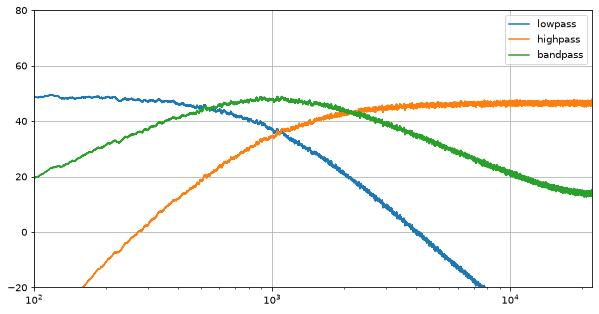

In [50]:
modes = ['lowpass', 'highpass', 'bandpass']

# A low drive keeps the saturation out of the picture.
get_power_spectrum_plot(
    *[ladder_filter(noise, 1000, 0., 0.1, mode) for mode in modes],
    labels=modes,
    ylim=(-20, 80),
    **log_axis,
)

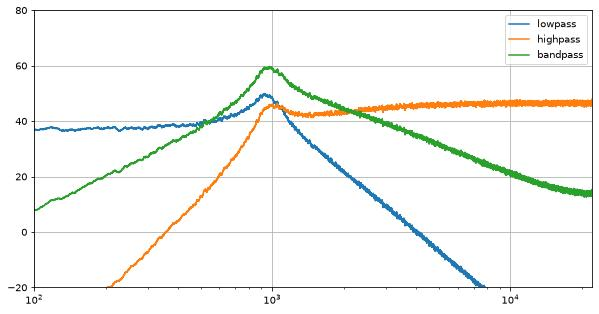

In [51]:
# The same, with resonance.
get_power_spectrum_plot(
    *[ladder_filter(noise, 1000, 3., 0.1, mode) for mode in modes],
    labels=modes,
    ylim=(-20, 80),
    **log_axis,
)

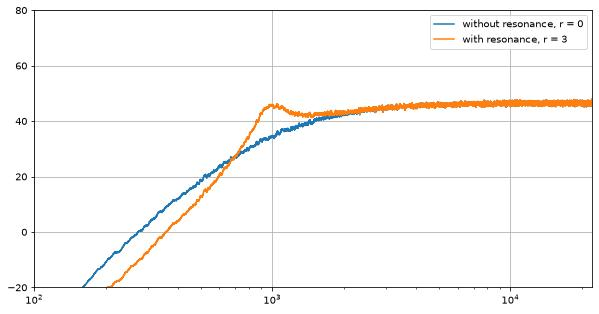

In [53]:
# The highpass, without resonance and with r = 3.
get_power_spectrum_plot(
    ladder_filter(noise, 1000, 0., 0.1, 'highpass'),
    ladder_filter(noise, 1000, 3., 0.1, 'highpass'),
    labels=['without resonance, r = 0', 'with resonance, r = 3'],
    ylim=(-20, 80),
    **log_axis,
)

## Step 8: Orders

A filter's **order** is the number of its poles. As we saw in step 2, each
chaser is one pole, and in step 3 we saw that each one adds another 6dB per
octave to the slope. Our ladder has four, so it is a fourth order filter,
cutting 24dB per octave.

A steeper slope is not always what we want, though. A gentler slope leaves
more of the highs in the sound, so it sounds brighter. That is part of why
Oberheim's SEM, with its two pole filter, sounds so different from a Moog, and
why people still argue whether the TB-303 cuts 18dB or 24dB per octave.

Our ladder can give us the lower orders too, without changing its loop at
all. A second order lowpass is $C^2$, two chasers in a row, and that is simply
the output of stage two, `y2`. A highpass of a lower order is a shorter row of
Pascal's triangle. For example, a third order highpass is $(1 - C)^3$, which
expands into $(1 - 3C + 3C^2 - C^3)$, or in code:

```
out = x - 3 * y1 + 3 * y2 - y3
```

A bandpass needs as many lowpasses as highpasses, so it comes in orders 2 and
4. The fourth order is the one from step 7, and the second order is
$C(1 - C)$, one of each, multiplied by 2 to bring its center back to full
strength:

```
out = 2 * y1 - 2 * y2
```

Let's add an `order` to our filter, with a mix for each mode and order:

In [98]:
@numba.njit(fastmath=True)
def ladder_filter(x, cutoff, r, drive, mode='lowpass', order=4):

    # The g of each chaser, from the cutoff frequency, as in step 2.
    g = cutoff2g(cutoff)

    y1 = y2 = y3 = y4 = 0.
    out = np.zeros(len(x))

    #
    # How much of the input u and of each stage y1 to y4 to mix, for
    # each mode and order.
    #
    mixes = {
        ('lowpass', 1): (0., 1., 0., 0., 0.),
        ('lowpass', 2): (0., 0., 1., 0., 0.),
        ('lowpass', 3): (0., 0., 0., 1., 0.),
        ('lowpass', 4): (0., 0., 0., 0., 1.),
        ('highpass', 1): (1., -1., 0., 0., 0.),
        ('highpass', 2): (1., -2., 1., 0., 0.),
        ('highpass', 3): (1., -3., 3., -1., 0.),
        ('highpass', 4): (1., -4., 6., -4., 1.),
        ('bandpass', 2): (0., 2., -2., 0., 0.),
        ('bandpass', 4): (0., 0., 4., -8., 4.),
    }
    m0, m1, m2, m3, m4 = mixes[mode, order]

    #
    # Make up for the level lost at low drive, where the filter is
    # nearly linear, so its output is the drive times the full level.
    # Above 1, driving harder is meant to be louder.
    #
    makeup = 1 / min(drive, 1.)

    for i in range(len(x)):
        # The input and every stage go through tanh, like the
        # transistors of the ladder.
        u = math.tanh(drive * x[i] - r * y4)
        y1 += g * (u - math.tanh(y1))
        y2 += g * (math.tanh(y1) - math.tanh(y2))
        y3 += g * (math.tanh(y2) - math.tanh(y3))
        y4 += g * (math.tanh(y3) - math.tanh(y4))

        # Mix the input and the stage outputs, as the mode says.
        out[i] = (m0 * u + m1 * y1 + m2 * y2 + m3 * y3 + m4 * y4) * makeup

        #
        # WARNING: do not remove this check. It stops the filter as
        # soon as its output passes 3, protecting you from a runaway
        # sound blasting out at full volume.
        #
        if abs(out[i]) > 3:
            raise ValueError('The filter ran away: its output passed 3.')

    return out

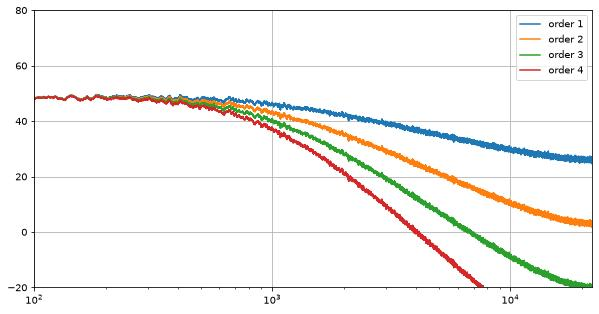

In [93]:
# Noise through the lowpass in orders 1 to 4, all at 1000Hz.
orders = [1, 2, 3, 4]

get_power_spectrum_plot(
    *[ladder_filter(noise, 1000, 0., 0.1, 'lowpass', n) for n in orders],
    labels=['order %d' % n for n in orders],
    ylim=(-20, 80),
    **log_axis,
)

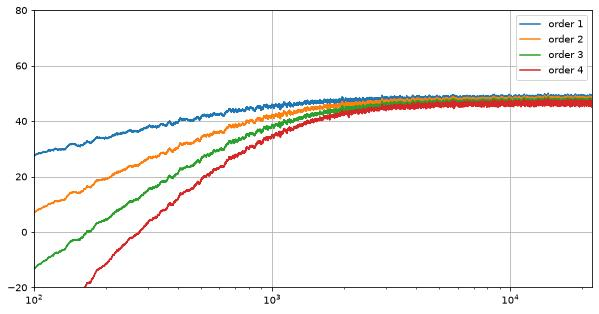

In [55]:
# The same for the highpass.
get_power_spectrum_plot(
    *[ladder_filter(noise, 1000, 0., 0.1, 'highpass', n) for n in orders],
    labels=['order %d' % n for n in orders],
    ylim=(-20, 80),
    **log_axis,
)

Each order adds another 6dB per octave to the slope.

## Wrapping up

We started with a single chaser, a resistor and a capacitor written as one
line of code, and ended with Moog's ladder: four chasers in a row for a steep
slope, feedback from the last one to the first for resonance, and tanh for the
gentle saturation of its transistors. Each part is only a few lines of code,
and each one changes the sound in a way we could see and hear.

Next time you hear a synth bass squelch, or a sound slowly open up as a filter
sweeps, you will know what is going on inside: a ladder of chasers, a little
feedback, and a touch of saturation. The three friends from Chicago who started
acid house found that sound by ear, turning the knobs of a machine they had no
idea how to use. You now have something more: you know how it works, and with
a few lines of code you can take it apart, change it, and build filters of
your own.